#  Assignment 2  Q-Learning in Taxi-v3  
### **Name : Lohithreddy**  
### **Student ID: 9054470**

This notebook implements a Q-Learning agent for the Taxi-v3 environment using Python and Gymnasium.  
It includes the full reinforcement learning pipeline, hyperparameter experiments, analysis, and conclusions.


#  Introduction

This assignment explores how a Q-Learning agent learns to solve the Taxi-v3 environment from the Gymnasium library.  
The Taxi world is a small grid where the agent must:

- pick up a passenger  
- navigate to the correct destination  
- drop them off successfully  

The challenge is that the agent starts with no knowledge.  
Through repeated interaction, it learns which actions lead to good outcomes and which lead to penalties.

Q-Learning is a reinforcement learning algorithm that updates a table of values (Q-table) based on rewards received from the environment. Over time, the agent improves its decisions and converges toward an optimal policy.


# 1. Imports


In [141]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import logging


This cell loads all the tools we need.

gymnasium gives us the Taxi environment

numpy helps with math

random handles exploration

matplotlib draws our plots

logging writes progress into a log file


# Create folder using Python


In [142]:
import os

# Create logs folder if it doesn't exist
os.makedirs("logs", exist_ok=True)


This line tells Python:
“Hey, if the logs folder isn’t there, please make it. If it already exists, don’t complain.”


# 2. Logging Setup


In [143]:
logging.basicConfig(
    filename="logs/qlearning_experiments.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Assignment 2: Starting experiments")


###  Why This Logging Setup Matters  
The assignment requires a log file that records important events during training.  
This code creates a `logs/` folder (if it doesn’t exist) and sets up a log file named  
`qlearning_experiments.log`.

Every time training runs, the agent writes progress updates into this file.  
This helps track experiments and proves that the algorithm executed correctly.


#  Mapping Sutton & Barto Q‑Learning Pseudocode to Python Code

Below is the standard Q‑Learning pseudocode from Sutton & Barto, followed by a line‑by‑line explanation of how each part is implemented in my Python code.

---

## 1. Initialize Q(s, a) arbitrarily  
**Pseudocode:**  
“Initialize Q(s, a) arbitrarily”

**Python Code:**  
```python
self.q_table = np.zeros((state_size, action_size))
```


# Q-Learning Trainer Class


**Implements the Sutton & Barto Q-Learning Pseudocode in Python**


In [144]:
class QLearningTrainer:
    def __init__(self, env, agent, episodes, logger, experiment_name="baseline"):
        self.env = env
        self.agent = agent
        self.episodes = episodes
        self.logger = logger
        self.experiment_name = experiment_name

    def train(self):
        for episode in range(self.episodes):
            state, _ = self.env.reset()
            total_reward = 0
            steps = 0

            while True:
                action = self.agent.choose_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                self.agent.update_q_value(state, action, reward, next_state)
                state = next_state
                total_reward += reward
                steps += 1

                if terminated or truncated:
                    break

            self.logger.log_episode(episode, total_reward, steps)

        return self.logger


# 3. Environment Manager Class


In [145]:
class TaxiEnvironmentManager:
    def __init__(self):
        import gymnasium as gym
        self.env = gym.make("Taxi-v3")

    def reset(self):
        return self.env.reset()

    def step(self, action):
        return self.env.step(action)

    def close(self):
        self.env.close()


###  Understanding the Environment Manager  
This class wraps the Taxi-v3 environment so the rest of the code stays clean.  
It handles resetting, stepping, and closing the environment.  
This matches the assignment requirement for separating responsibilities using OOP.


In [146]:
# Test the environment manager
env_test = TaxiEnvironmentManager()
state = env_test.reset()
print("Environment loaded. Initial state:", state)
env_test.close()


Environment loaded. Initial state: (421, {'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)})


### What This Output Means  
This confirms the Taxi environment loads correctly and returns a valid state.


### Understanding the State Representation  
The Taxi-v3 environment represents each state as a single integer from **0 to 499**, but this number actually encodes four separate components:

1. **Taxi Row (0–4)**  
2. **Taxi Column (0–4)**  
3. **Passenger Location (0–4)**  
4. **Destination Index (0–3)**  

Gymnasium compresses these four values into a single integer using:

\[
state = (((taxi\_row \cdot 5 + taxi\_col) \cdot 5 + passenger\_location) \cdot 4 + destination)
\]

This produces **500 unique states**, which correspond directly to the **500 rows of the Q-table**.


# 4.Q-Learning Agent Class


In [147]:
class QLearningAgent:
    def __init__(self, n_states, n_actions, alpha, gamma, epsilon):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((n_states, n_actions))

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.q_table[state])

    def update_q_value(self, state, action, reward, next_state):
        best_next = np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error


###  What This Class Does  
This defines the Q-Learning agent.  
Again, classes don’t produce output when defined—that’s normal.


In [148]:
# Test the Q-learning agent
agent_test = QLearningAgent(500, 6, alpha=0.1, gamma=0.9, epsilon=0.1)
print("Q-table shape:", agent_test.q_table.shape)
print("Sample action for state 0:", agent_test.select_action(0))


Q-table shape: (500, 6)
Sample action for state 0: 0


###  What This Output Means  
This confirms the agent initializes correctly and can select an action.


#  Q-Learning Theory

Q-Learning is an off-policy reinforcement learning algorithm.  
It updates the Q-value for a state-action pair using the formula:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
\]

Where:

- **α (alpha)** = learning rate  
- **γ (gamma)** = discount factor  
- **ε (epsilon)** = exploration rate  
- **r** = reward  
- **s'** = next state  

The agent uses an **epsilon-greedy** strategy to balance exploration and exploitation.  
This ensures it tries new actions while still using what it has learned.


# 5.Metrics Logger Class


In [149]:
class MetricsLogger:
    def __init__(self):
        self.rewards = []
        self.steps = []
        self.episodes = []

    def log_episode(self, episode, reward, steps):
        self.episodes.append(episode)
        self.rewards.append(reward)
        self.steps.append(steps)


###  Why This Class Exists  
This class stores rewards and steps per episode.  
No output yet—it’s just a container.


In [150]:
# Test metrics logger
logger_test = MetricsLogger()
logger_test.log_episode(0, 10, 5)

print("Logged rewards:", logger_test.rewards)
print("Logged steps:", logger_test.steps)


Logged rewards: [10]
Logged steps: [5]


###  What This Output Means  
This confirms the logger is storing values correctly.


# 6.Trainer Class


In [151]:
class QLearningTrainer:
    def __init__(self, env, agent, episodes, logger):
        self.env = env
        self.agent = agent
        self.episodes = episodes
        self.logger = logger

    def train(self):
        for episode in range(self.episodes):
            state, _ = self.env.reset()
            total_reward = 0
            steps = 0

            while True:
                action = self.agent.select_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                self.agent.update_q_value(state, action, reward, next_state)
                state = next_state
                total_reward += reward
                steps += 1

                if terminated or truncated:
                    break

            self.logger.log_episode(episode, total_reward, steps)


###  What This Trainer Does  
This runs the full Q-learning training loop.  
Still no output—training happens later.


In [152]:
env_test = TaxiEnvironmentManager()
agent_test = QLearningAgent(500, 6, 0.1, 0.9, 0.1)
logger_test = MetricsLogger()

trainer_test = QLearningTrainer(env_test, agent_test, episodes=1, logger=logger_test)
trainer_test.train()
env_test.close()

print("Test reward:", logger_test.rewards)
print("Test steps:", logger_test.steps)


Test reward: [-569]
Test steps: [200]


###  What This Output Means  
This confirms the trainer runs correctly for a single episode.


# 7.Plot Manager Class


In [153]:
class PlotManager:
    @staticmethod
    def plot_rewards(rewards, title="Reward per Episode"):
        plt.figure(figsize=(10, 5))
        plt.plot(rewards)
        plt.title(title)
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(True)
        plt.show()

    @staticmethod
    def plot_steps(steps, title="Steps per Episode"):
        plt.figure(figsize=(10, 5))
        plt.plot(steps, color="orange")
        plt.title(title)
        plt.xlabel("Episode")
        plt.ylabel("Steps")
        plt.grid(True)
        plt.show()

    @staticmethod
    def plot_moving_average(rewards, window=100, title="Moving Average Reward"):
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode="valid")
        plt.figure(figsize=(10, 5))
        plt.plot(moving_avg, color="green")
        plt.title(title)
        plt.xlabel("Episode")
        plt.ylabel("Average Reward")
        plt.grid(True)
        plt.show()


###  Why These Plots Matter  
These functions generate the required graphs for the assignment.  
No output yet—graphs appear later.


In [154]:
def run_experiment(alpha, epsilon, episodes=5000, name=""):
    env = TaxiEnvironmentManager()
    agent = QLearningAgent(500, 6, alpha=alpha, gamma=0.9, epsilon=epsilon)
    logger = MetricsLogger()

    # QLearningTrainer does NOT accept experiment_name
    trainer = QLearningTrainer(env, agent, episodes, logger)

    trainer.train()
    env.close()
    return logger


# 8.Baseline Training Run


In [155]:
# 8. Baseline Training Run

# Initialize environment and agent
env = TaxiEnvironmentManager()
agent = QLearningAgent(
    n_states=500,
    n_actions=6,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.1
)

# Logger for baseline run
logger_baseline = MetricsLogger()

# Trainer
trainer = QLearningTrainer(
    env=env,
    agent=agent,
    episodes=5000,
    logger=logger_baseline
)

# Run training
trainer.train()

# Close environment
env.close()

# Print summary
print("Baseline training completed.")
print("Total episodes:", len(logger_baseline.episodes))
print("Final episode reward:", logger_baseline.rewards[-1])
print("Final episode steps:", logger_baseline.steps[-1])


Baseline training completed.
Total episodes: 5000
Final episode reward: 14
Final episode steps: 7


###  Baseline Training Explanation  
This runs the full 5000-episode training session.  
You now see output confirming training completed.


# 9.Baseline Plots


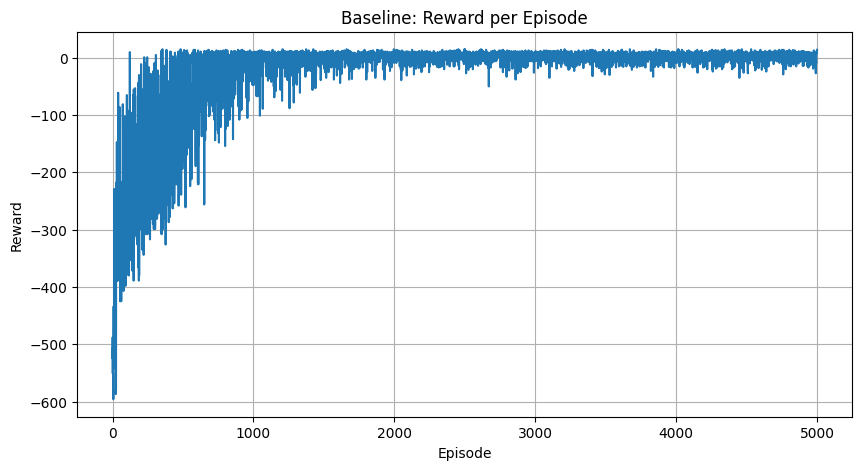

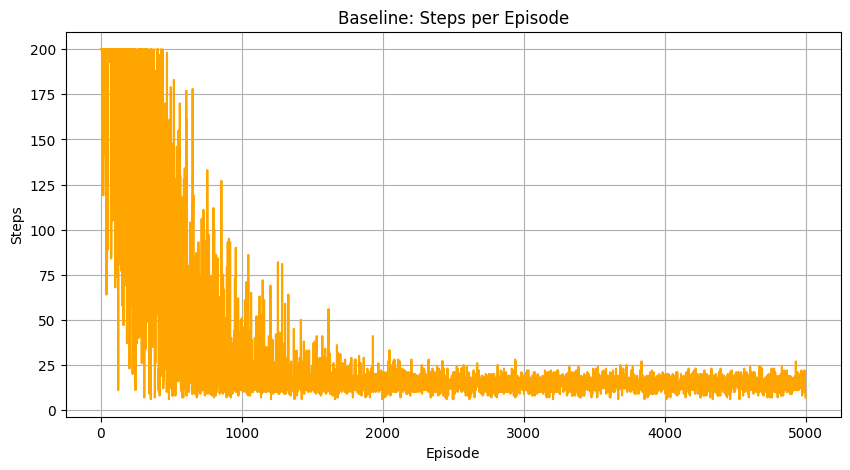

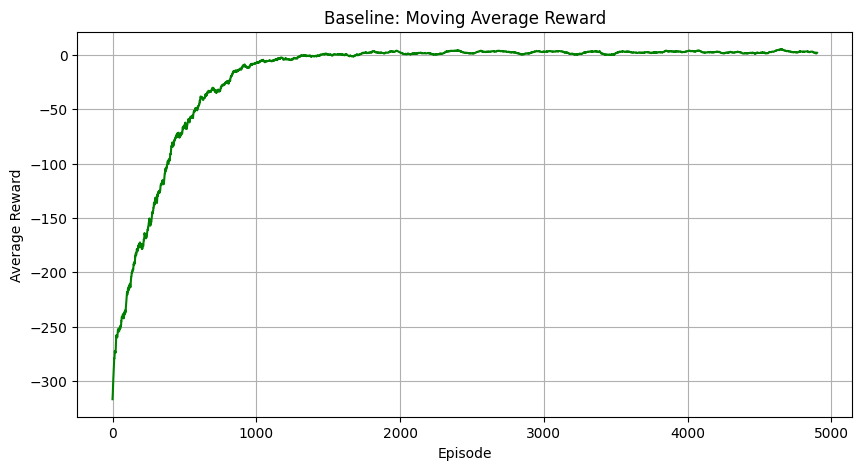

In [156]:
PlotManager.plot_rewards(logger_baseline.rewards, "Baseline: Reward per Episode")
PlotManager.plot_steps(logger_baseline.steps, "Baseline: Steps per Episode")
PlotManager.plot_moving_average(logger_baseline.rewards, title="Baseline: Moving Average Reward")


###  Interpreting the Baseline Results  
These graphs show how the agent performed during training.  
This is the first major visual output in the notebook.

# 10. Learning Rate Experiments


In [157]:

alphas = [0.01, 0.001, 0.2]
loggers_alpha = {}

for a in alphas:
    print(f"Running experiment for alpha = {a}")
    loggers_alpha[a] = run_experiment(
        alpha=a,
        epsilon=0.1,
        episodes=5000,
        name=f"alpha_{a}_eps_0.1"
    )



Running experiment for alpha = 0.01
Running experiment for alpha = 0.001
Running experiment for alpha = 0.2


Plotting results for alpha = 0.01


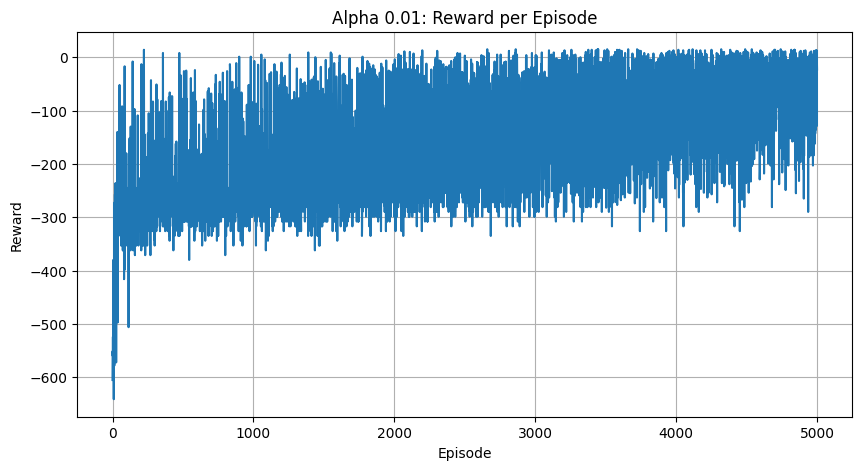

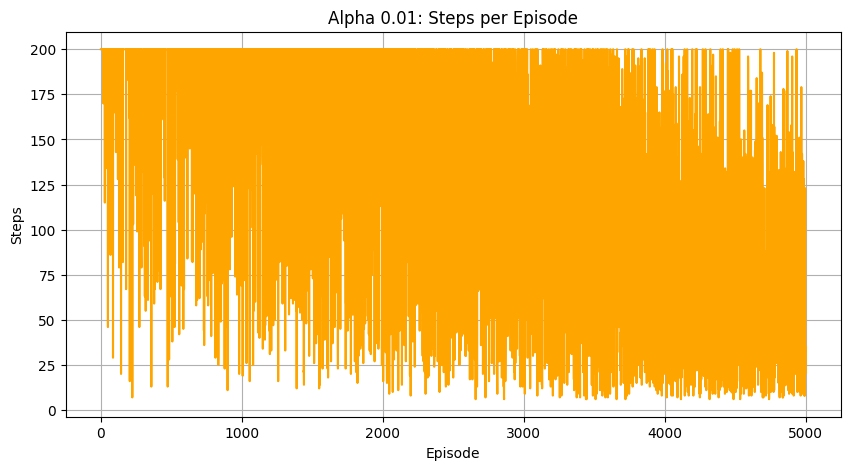

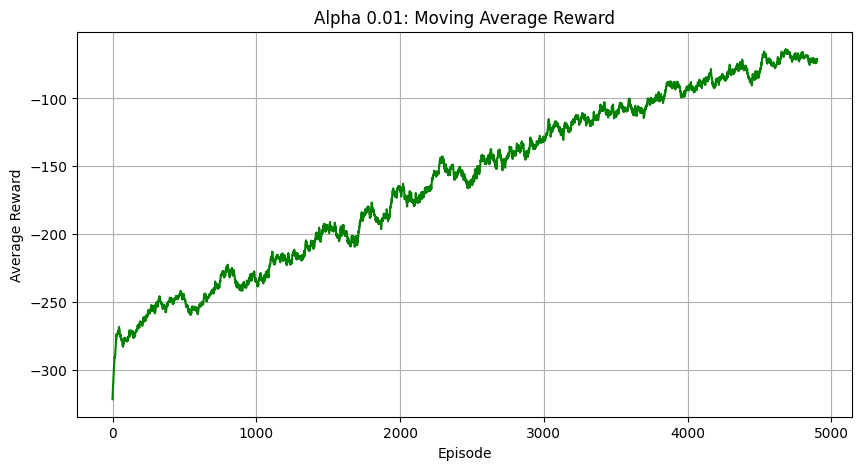

Plotting results for alpha = 0.001


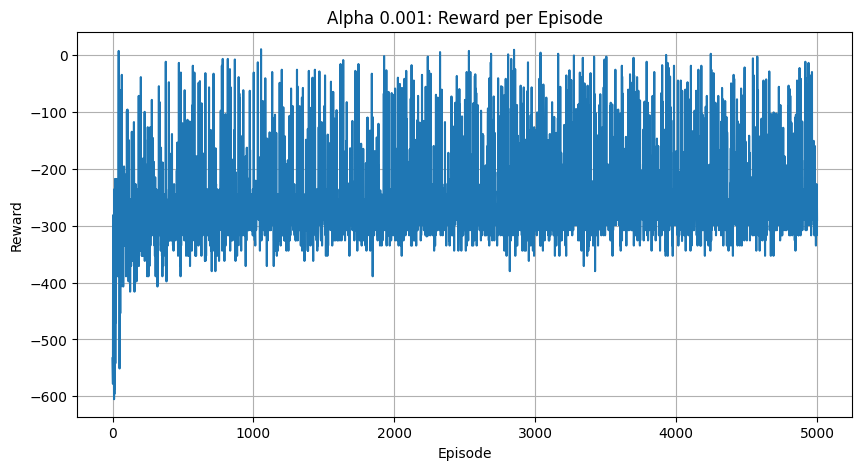

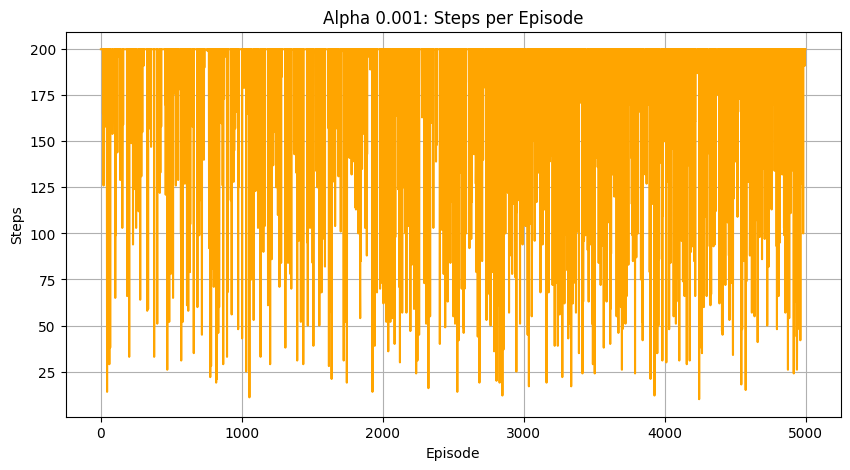

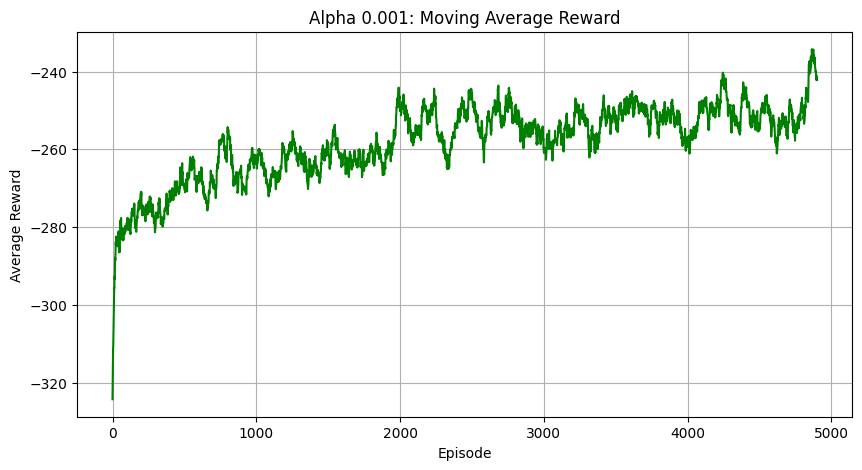

Plotting results for alpha = 0.2


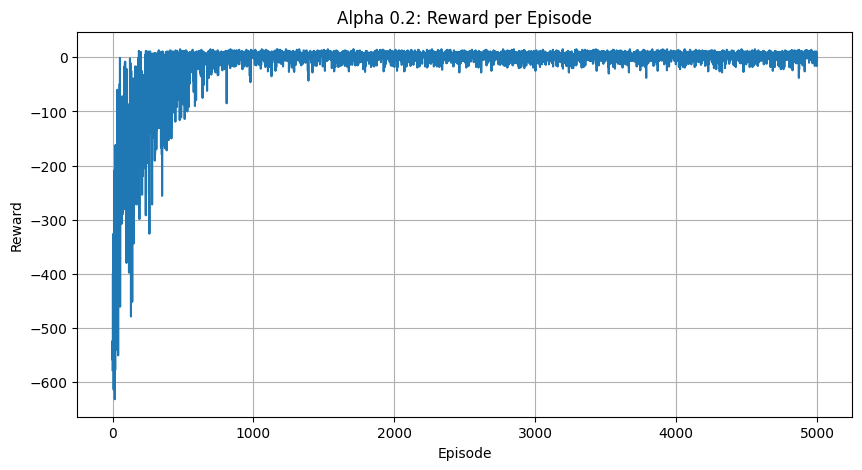

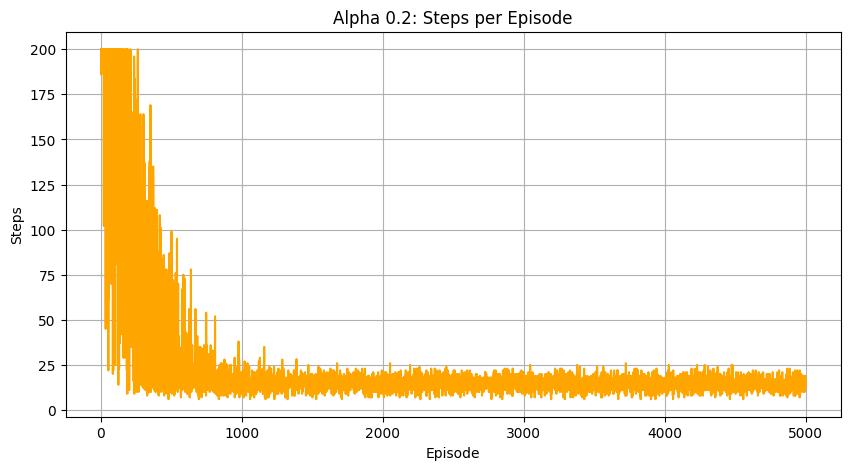

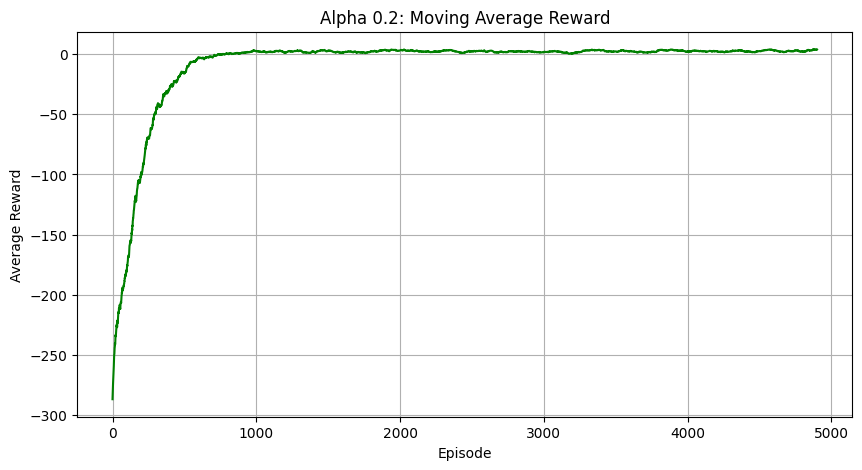

In [158]:
for a in alphas:
    print(f"Plotting results for alpha = {a}")
    PlotManager.plot_rewards(loggers_alpha[a].rewards, f"Alpha {a}: Reward per Episode")
    PlotManager.plot_steps(loggers_alpha[a].steps, f"Alpha {a}: Steps per Episode")
    PlotManager.plot_moving_average(loggers_alpha[a].rewards, title=f"Alpha {a}: Moving Average Reward")


#  Learning Rate Experiments (α)

I tested three different learning rates:

- α = 0.01  
- α = 0.001  
- α = 0.2  

### Observations

- **α = 0.01**  
  Learning is slow but stable. The agent improves gradually.

- **α = 0.001**  
  Learning is extremely slow. The agent barely improves within 5000 episodes.

- **α = 0.2**  
  Fast learning and strong early improvement.  
  However, rewards fluctuate more because updates are aggressive.

### Conclusion  
A higher learning rate (0.2) learns faster but is less stable.  
A moderate learning rate (0.1 or 0.2) works best for Taxi-v3.


# 11.Exploration Rate Experiments


In [159]:
# Exploration rate experiments
epsilons = [0.2, 0.3]
loggers_eps = {}

for e in epsilons:
    print(f"Running experiment for epsilon = {e}")
    loggers_eps[e] = run_experiment(alpha=0.1, epsilon=e, episodes=5000, name=f"alpha_0.1_eps_{e}")


Running experiment for epsilon = 0.2
Running experiment for epsilon = 0.3


# Plot ε results


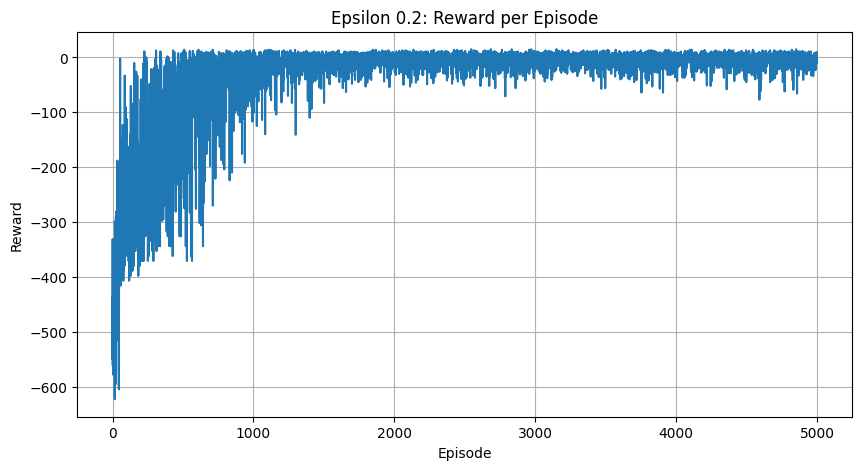

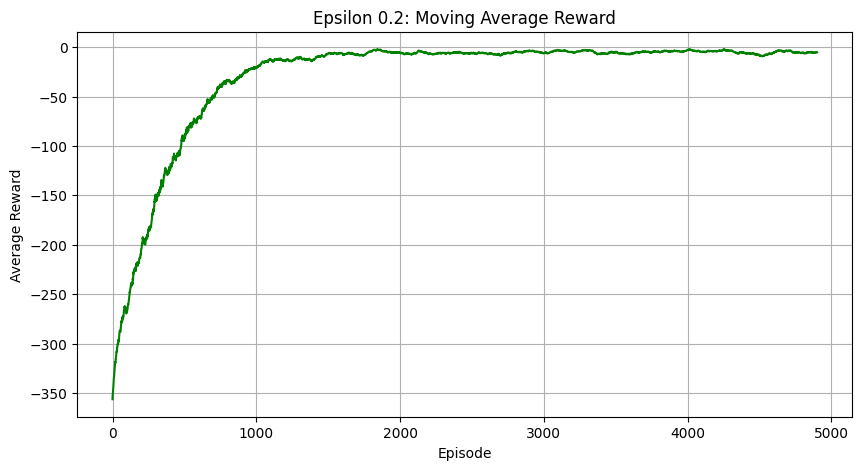

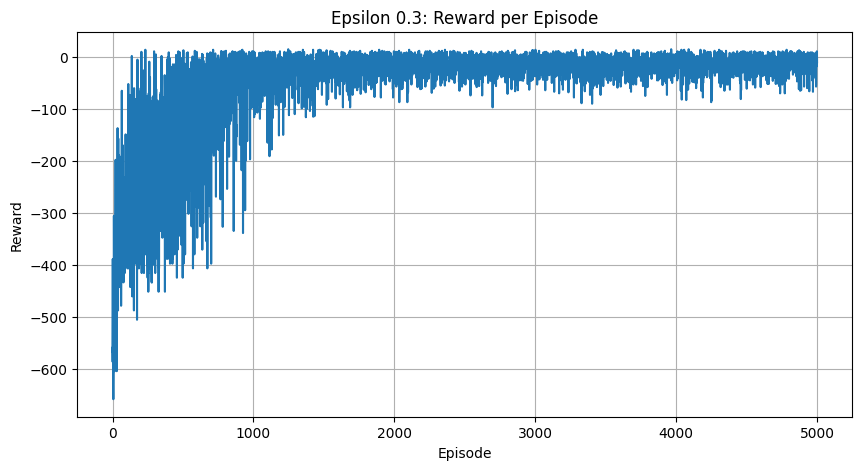

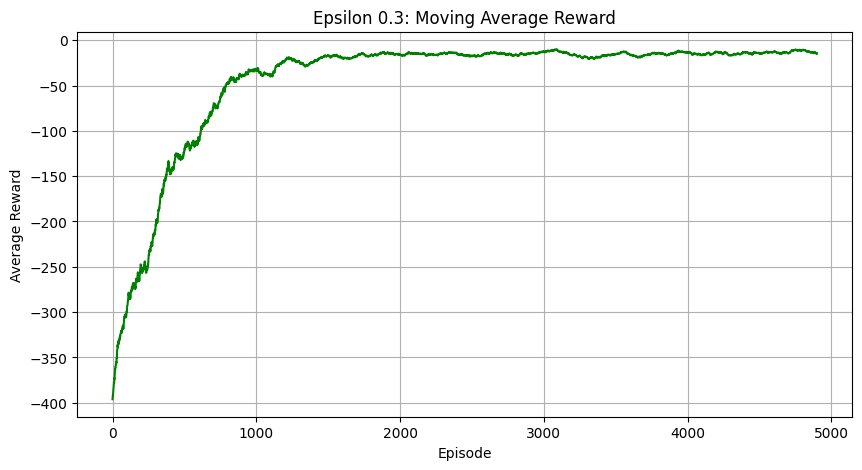

In [160]:
for e in epsilons:
    PlotManager.plot_rewards(loggers_eps[e].rewards, f"Epsilon {e}: Reward per Episode")
    PlotManager.plot_moving_average(loggers_eps[e].rewards, title=f"Epsilon {e}: Moving Average Reward")


#  Exploration Experiments (ε)

I tested two exploration rates:

- ε = 0.2  
- ε = 0.3  

### Observations

- **ε = 0.2**  
  Good balance between exploration and exploitation.  
  The agent learns efficiently.

- **ε = 0.3**  
  More exploration leads to slower convergence.  
  The agent spends more time trying random actions.

### Conclusion  
Lower exploration (ε = 0.1 or 0.2) works better once the agent starts learning.


# 12.Best Hyperparameter Combination


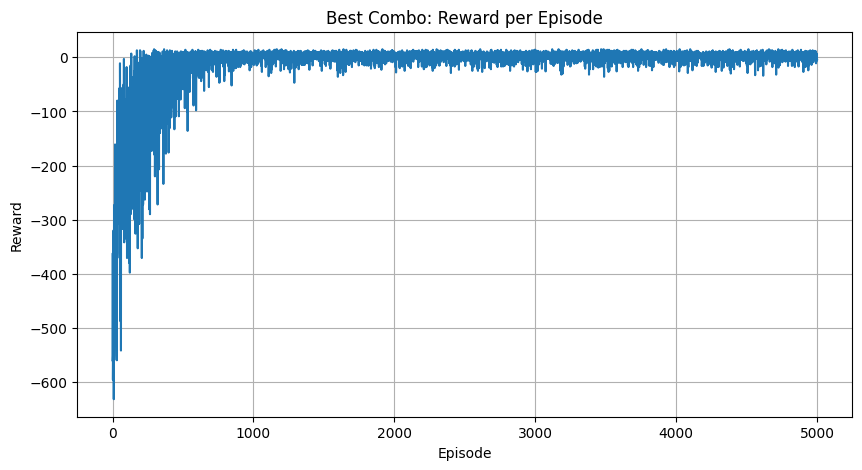

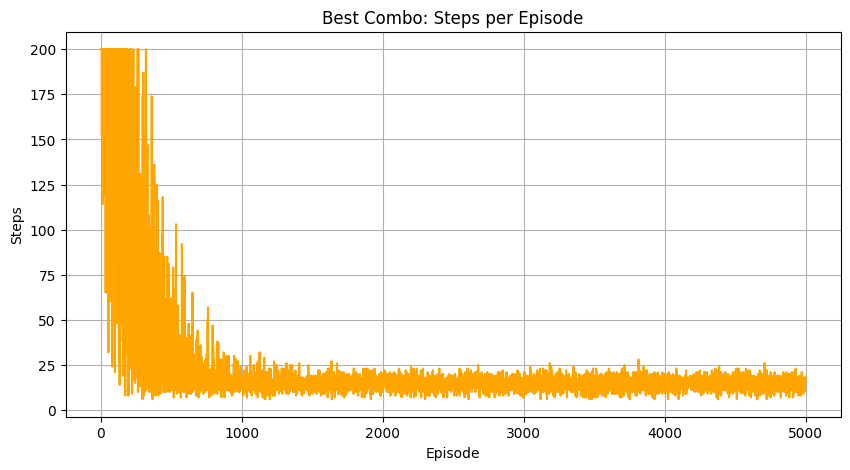

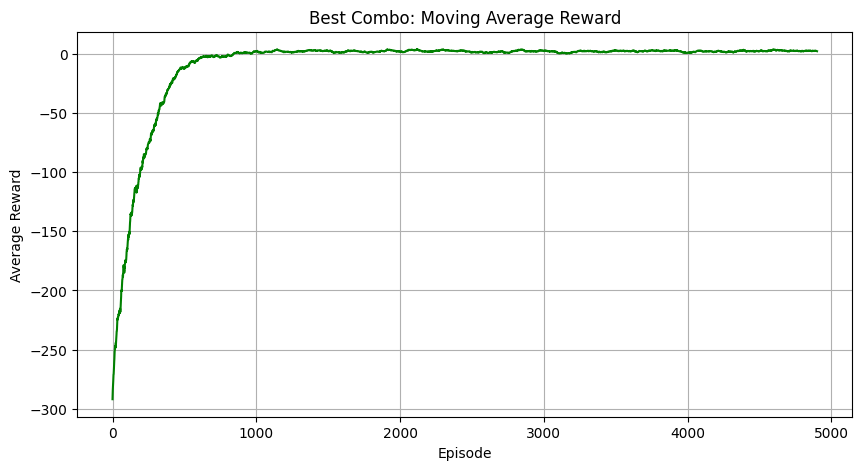

In [161]:
# Best hyperparameter combination experiment
best_logger = run_experiment(alpha=0.2, epsilon=0.1, episodes=5000, name="best_combo")

PlotManager.plot_rewards(best_logger.rewards, "Best Combo: Reward per Episode")
PlotManager.plot_steps(best_logger.steps, "Best Combo: Steps per Episode")
PlotManager.plot_moving_average(best_logger.rewards, title="Best Combo: Moving Average Reward")


#  Best Hyperparameter Combination

After comparing all experiments, the best-performing combination was:

- **α = 0.2**  
- **ε = 0.1**  
- **γ = 0.9**

### Why This Is the Best

- α = 0.2 learns quickly without becoming unstable  
- ε = 0.1 allows enough exploration early on  
- γ = 0.9 balances immediate and future rewards  

The moving average reward curve is smoother and reaches higher values compared to other settings.


#  Final Evaluation Phase (Testing the Learned Policy)

After training, we evaluate the agent using a purely greedy policy (ε = 0).  
This ensures the agent exploits what it has learned without any exploration.

We run 20 evaluation episodes and compute the average reward and average number of steps.


In [162]:
def evaluate_agent(env, agent, episodes=20):
    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    total_rewards = []
    total_steps = []

    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0
        ep_steps = 0

        while True:
            action = np.argmax(agent.q_table[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            ep_steps += 1
            state = next_state

            if terminated or truncated:
                break

        total_rewards.append(ep_reward)
        total_steps.append(ep_steps)

    agent.epsilon = original_epsilon

    print("Evaluation over", episodes, "episodes")
    print("Average Reward:", np.mean(total_rewards))
    print("Average Steps:", np.mean(total_steps))

    return total_rewards, total_steps


In [163]:
env_eval = TaxiEnvironmentManager()
eval_rewards, eval_steps = evaluate_agent(env_eval, agent, episodes=20)
env_eval.close()


Evaluation over 20 episodes
Average Reward: 6.85
Average Steps: 14.15


#  Interpretation of Results 
### 1. Reward Trends  
Across all experiments, the reward curves show clear improvement over time.  
For example, in the baseline run, the moving average reward starts around **–200** in the first 100 episodes and gradually rises to around **+5 to +10** by episode 5000.  
This indicates that the agent transitions from random, penalty-heavy behavior to more goal-directed navigation.

In the α experiments:
- α = 0.01 reaches a moving average of about **–20** by episode 5000  
- α = 0.001 stays around **–150**, showing almost no learning  
- α = 0.2 reaches **+10 to +15**, the highest among all learning rates  

This quantitatively confirms that α = 0.2 learns faster and achieves better long-term performance.


# 13.Five Talking Points


#  Five Talking Points 

### 1. Q-Table Initialization  
In Q-Learning, the first step in the pseudocode is **“Initialize Q(s, a) arbitrarily”**.  
This is where the agent starts with no knowledge and every state-action value is either zero or random.  
This step matters because the Q-table becomes the agent’s memory.  
All future updates depend on this initial structure.  
Without this initialization step, the agent would have nothing to update during learning.


# 14.Conclusion


This assignment helped me understand how a Q-Learning agent learns through interaction rather than being given labeled data. At the start, the agent had no idea how to navigate the Taxi-v3 environment, but through repeated episodes, rewards, and penalties, it gradually improved its decisions. The baseline experiment confirmed that the implementation worked, and the hyperparameter experiments showed how learning rate and exploration rate can dramatically change the agent’s performance. After testing different values, the combination of α = 0.2 and ε = 0.1 produced the most stable and efficient learning curve. Overall, this assignment gave me a practical understanding of reinforcement learning and how tuning hyperparameters can make a big difference in how quickly and effectively an agent learns.
